In [1]:
import warnings
warnings.filterwarnings('ignore')
from fastai.vision.all import *
from datasets import load_dataset

In [2]:
ds = load_dataset("beans")
label_names = ['angular_leaf_spot', 'bean_rust', 'healthy']
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


In [3]:
from pathlib import Path

path = Path('beans')

for label in label_names:
    (path/label).mkdir(parents=True, exist_ok=True)

for i in range(len(ds['train'])):
    img = ds['train'][i]['image']
    label = label_names[ds['train'][i]['labels']]
    img.save(path/label/f'{i}.jpg')

print("Done")

Done


In [4]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

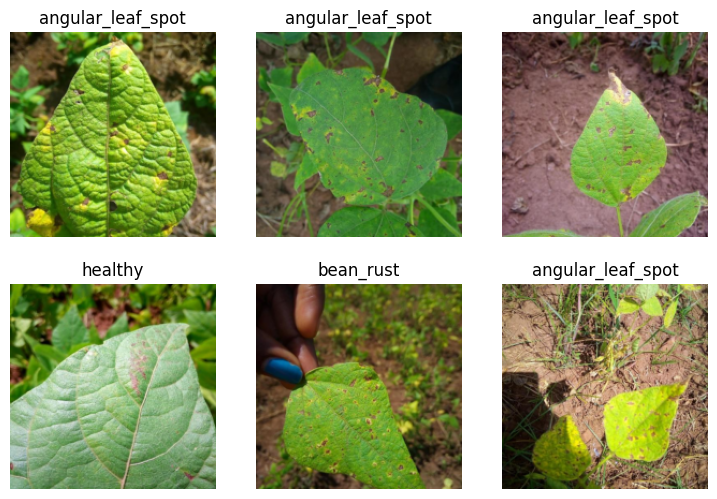

In [7]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [8]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.335355,0.486398,0.155340,00:24


epoch,train_loss,valid_loss,error_rate,time
0,0.475588,0.350330,0.101942,00:29
1,0.307073,0.262937,0.082524,00:31
2,0.195637,0.262425,0.082524,00:29


In [12]:
img = PILImage.create('test.jpg')
pred, idx, probs = learn.predict(img)
print(f"This is: {pred}")
print(f"Confidence: {probs[idx]*100:.1f}%")

This is: angular_leaf_spot
Confidence: 88.3%
